In [1]:
from scformer.utils import (
    compute_ilisi,
    compute_ari,
    compute_nmi,
    compute_nn_entropy,
    compute_silhouette_score,
    compute_calinski_harabasz_score,
    compute_davies_bouldin_score,
)

In [2]:
import pandas as pd
from warnings import filterwarnings
import random
import torch
import numpy as np
import os
import scanpy as sc

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
adata = sc.read_h5ad('cache/pan_cancer_matrix.h5ad')
adata_ESCA = adata[adata.obs['Cancer'] == 'ESCA']
PatientID = adata_ESCA.obs['PatientID'].unique()
adata_subset = adata_ESCA[adata_ESCA.obs['PatientID'].isin(list(PatientID)[0:2])]

In [4]:
output_file = 'data/pan_cancer/output/ESCA'

In [5]:
node_ids = np.load(output_file + "/node_ids.npy")
cell_emb = np.load(output_file + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata_subset.obsm["cell_emb"] = cell_emb_sorted.values

In [6]:
pred = np.load(output_file + '/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata_subset.obs['pre'] = pred_sorted.values
adata_subset.obs['pre'] = adata_subset.obs['pre'].astype('category')

In [7]:
adata_subset

AnnData object with n_obs × n_vars = 2630 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation', 'pre'
    obsm: 'cell_emb'

In [8]:
# Load example single-cell data after batch correction
# Assuming the data is saved in a CSV file where each row is a cell and each column is a gene/feature
corrected_data = adata_subset.obsm['cell_emb']
# Load batch labels, assuming they are stored in a separate CSV file or in the same dataframe
labels = adata_subset.obs['PatientID']

# # Compute LISI
# lisi_scores = compute_lisi(corrected_data, labels, k=30)
# print(lisi_scores)
# 
# # Optionally, visualize the distribution of LISI scores
# import matplotlib.pyplot as plt
# 
# plt.hist(lisi_scores, bins=20, edgecolor='black')
# plt.xlabel('LISI Score')
# plt.ylabel('Frequency')
# plt.title('Distribution of LISI Scores after Batch Correction')
# plt.show()
ilisi_score = compute_ilisi(corrected_data, labels)
nmi_score = compute_nmi(adata_subset.obs['Annotation'], adata_subset.obs['pre'])
ari_score = compute_ari(adata_subset.obs['Annotation'], adata_subset.obs['pre'])
nn_entropy_scores = compute_nn_entropy(corrected_data, labels, k=30)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

1.490859990451036 0.4846693894221802 0.29006591771126533 0.44659237367578974


In [9]:
sc_score = compute_silhouette_score(corrected_data, adata_subset.obs['pre'])
ch_score = compute_calinski_harabasz_score(corrected_data, adata_subset.obs['pre'])
db_score = compute_davies_bouldin_score(corrected_data, adata_subset.obs['pre'])
sc_score, ch_score, db_score

(0.42644295, 615.0494557494129, 0.8090029498682882)

In [10]:
sc.pp.normalize_total(adata_subset, target_sum=1e4)
sc.pp.log1p(adata_subset)
sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000)
adata_subset = adata_subset[:, adata_subset.var['highly_variable']]

# 3. 执行 PCA 降维
sc.pp.pca(adata_subset, n_comps=50)

In [11]:
# sc.pp.neighbors(adata_subset, use_rep='X_pca')
# sc.tl.umap(adata_subset)
# sc.tl.leiden(adata_subset)

In [12]:
# sc.pl.umap(adata_subset, color=['leiden', 'PatientID', 'Annotation'])

In [16]:
import harmonypy as hm

# 4. 使用 Harmony 进行批次矫正
# `adata.obsm['X_pca']` 存储了 PCA 结果，`batch` 列表中存储每个细胞的批次标签
harmony_out = hm.run_harmony(adata_subset.obsm['X_pca'], adata_subset.obs, 'PatientID')

# 5. 将矫正后的数据存储回 AnnData
adata_subset.obsm['X_harmony'] = harmony_out.Z_corr.T

# 6. 后续分析，如聚类、可视化
sc.pp.neighbors(adata_subset, use_rep='X_harmony')
sc.tl.umap(adata_subset)
sc.tl.leiden(adata_subset)

2024-11-15 15:24:03,416 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-11-15 15:24:04,060 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-11-15 15:24:04,070 - harmonypy - INFO - Iteration 1 of 10
2024-11-15 15:24:04,384 - harmonypy - INFO - Iteration 2 of 10
2024-11-15 15:24:04,662 - harmonypy - INFO - Iteration 3 of 10
2024-11-15 15:24:04,932 - harmonypy - INFO - Iteration 4 of 10
2024-11-15 15:24:05,154 - harmonypy - INFO - Iteration 5 of 10
2024-11-15 15:24:05,294 - harmonypy - INFO - Iteration 6 of 10
2024-11-15 15:24:05,432 - harmonypy - INFO - Iteration 7 of 10
2024-11-15 15:24:05,558 - harmonypy - INFO - Iteration 8 of 10
2024-11-15 15:24:05,747 - harmonypy - INFO - Iteration 9 of 10
2024-11-15 15:24:05,916 - harmonypy - INFO - Iteration 10 of 10
2024-11-15 15:24:06,058 - harmonypy - INFO - Stopped before convergence


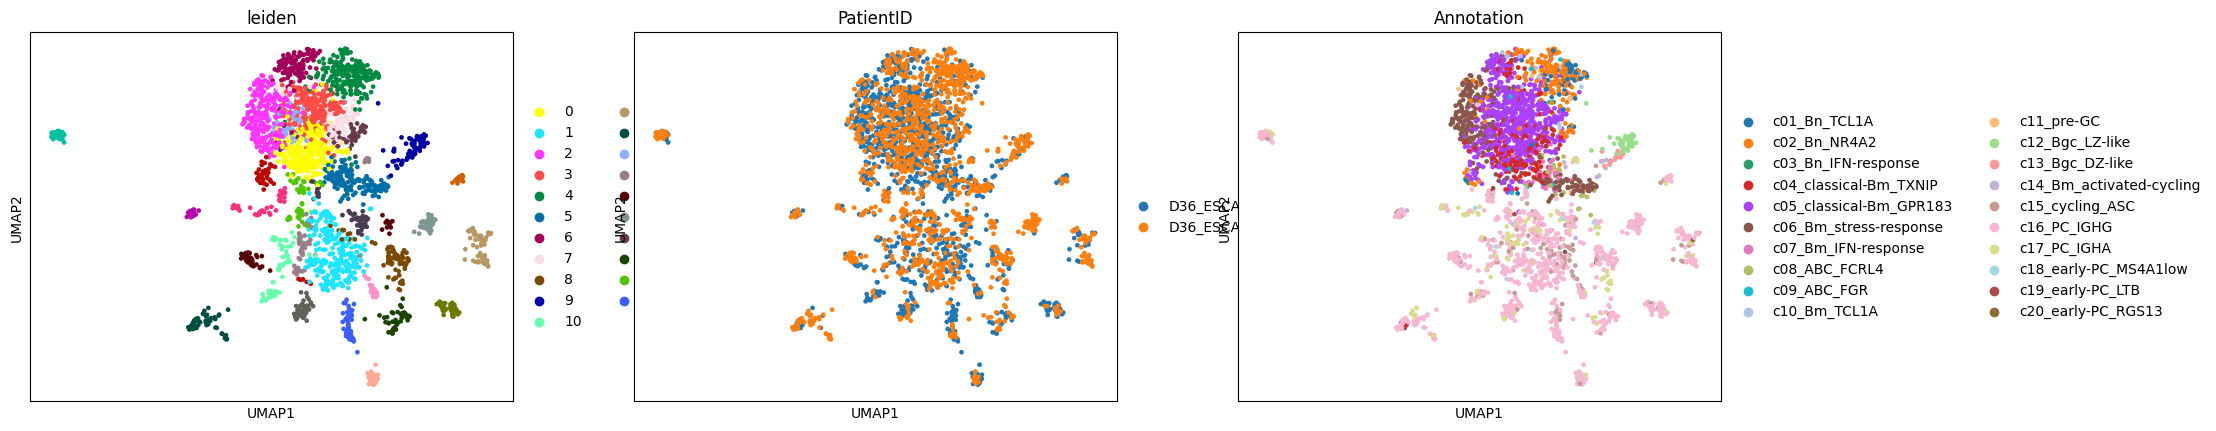

In [17]:
sc.pl.umap(adata_subset, color=['leiden', 'PatientID', 'Annotation'])

In [18]:
ilisi_score = compute_ilisi(harmony_out.Z_corr.T, labels)
nmi_score = compute_nmi(adata_subset.obs['Annotation'], adata_subset.obs['leiden'])
ari_score = compute_ari(adata_subset.obs['Annotation'], adata_subset.obs['leiden'])
nn_entropy_scores = compute_nn_entropy(harmony_out.Z_corr.T, labels)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

1.771980586120751 0.42302524416040477 0.16582979598344144 0.6094819635559546


In [19]:
sc_score = compute_silhouette_score(harmony_out.Z_corr.T, adata_subset.obs['leiden'])
ch_score = compute_calinski_harabasz_score(harmony_out.Z_corr.T, adata_subset.obs['leiden'])
db_score = compute_davies_bouldin_score(harmony_out.Z_corr.T, adata_subset.obs['leiden'])
sc_score, ch_score, db_score

(0.08384853, 77.84350217489362, 2.1495778372812633)

[[0.         0.98433829]
 [0.         0.        ]]
Processing datasets D36_ESCA.P20190404 <=> D36_ESCA.P20190410


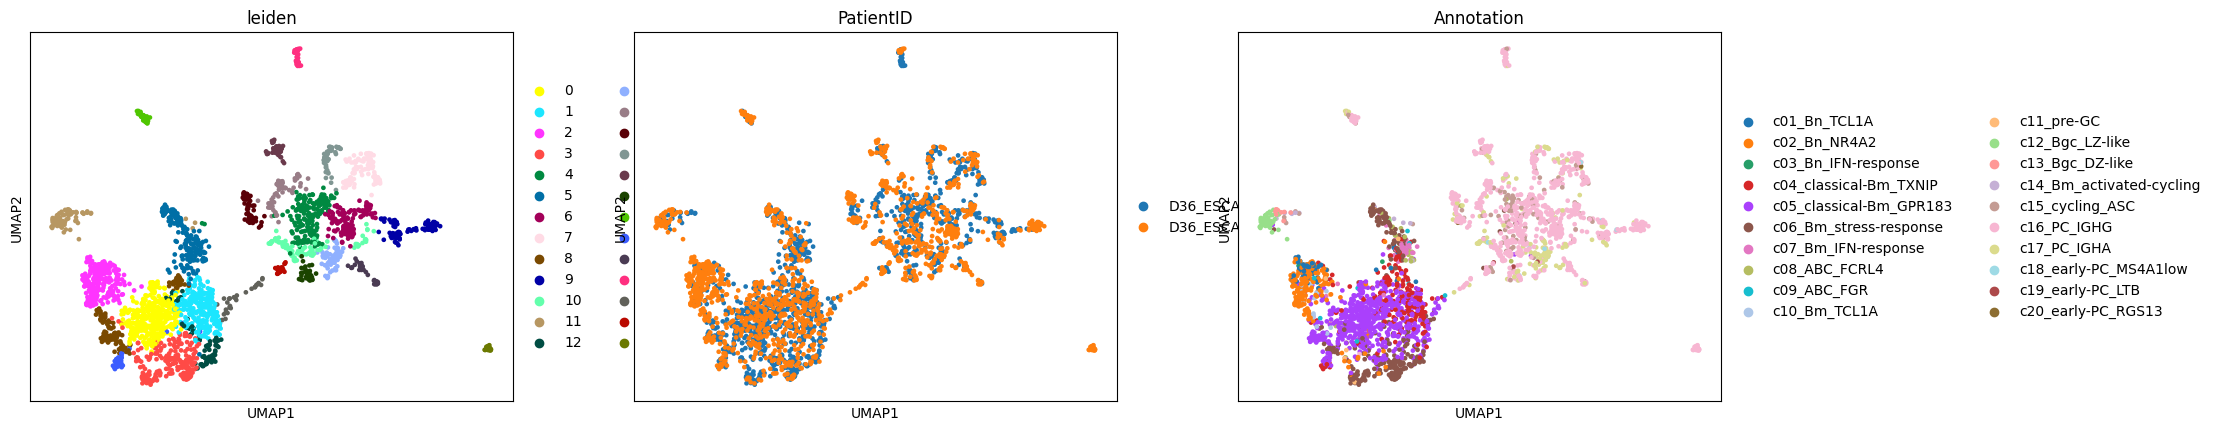

In [20]:
import scanpy as sc
import pandas as pd
import numpy as np

# 按批次分割数据
batch_key = 'PatientID'  # 确保在 adata.obs 中有一个列叫做 'batch' 来表示不同的批次
sc.external.pp.scanorama_integrate(adata_subset, key=batch_key)

sc.pp.neighbors(adata_subset, use_rep='X_scanorama')
sc.tl.umap(adata_subset)
sc.tl.leiden(adata_subset)

# 可视化矫正后的数据
sc.pl.umap(adata_subset, color=['leiden', 'PatientID', 'Annotation'])


In [21]:
ilisi_score = compute_ilisi(adata_subset.obsm['X_scanorama'], labels)
nmi_score = compute_nmi(adata_subset.obs['Annotation'], adata_subset.obs['leiden'])
ari_score = compute_ari(adata_subset.obs['Annotation'], adata_subset.obs['leiden'])
nn_entropy_scores = compute_nn_entropy(adata_subset.obsm['X_scanorama'], labels)
print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)

1.416519062304176 0.46210605252224507 0.21822874501522477 0.39166167893515846


In [22]:
sc_score = compute_silhouette_score(adata_subset.obsm['X_scanorama'], adata_subset.obs['leiden'])
ch_score = compute_calinski_harabasz_score(adata_subset.obsm['X_scanorama'], adata_subset.obs['leiden'])
db_score = compute_davies_bouldin_score(adata_subset.obsm['X_scanorama'], adata_subset.obs['leiden'])
sc_score, ch_score, db_score

(0.12828209, 120.87879981817562, 1.8728363433310133)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
methods = ['NDR', 'Harmony', 'Scanorama']
metrics = ['iLisi', 'NMI', 'ARI', 'nn entropy']

values = {
    'NDR': [1.490859990451036, 0.4846693894221802, 0.29006591771126533, 0.44659237367578974],
    'Harmony': [1.8197257061130114, 0.47021888877043316, 0.2380417825286289, 0.6308627760953233],
    'Scanorama': [1.4930015100969394, 0.48904356848721386, 0.20920974707572468, 0.4527420792999329]
}

# 设置柱状图的位置
bar_width = 0.2
index = np.arange(len(metrics))

# 创建绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制每个方法的柱状图
bar_NDR = ax.bar(index - bar_width, values['NDR'], bar_width, label='NDR')
bar_Harmony = ax.bar(index, values['Harmony'], bar_width, label='Harmony')
bar_Scanorama = ax.bar(index + bar_width, values['Scanorama'], bar_width, label='Scanorama')

# 添加标签
ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Metrics Comparison for NDR, Harmony, and Scanorama')
ax.set_xticks(index)
ax.set_xticklabels(metrics)


# 在柱子上显示数值
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)


add_value_labels(bar_NDR)
add_value_labels(bar_Harmony)
add_value_labels(bar_Scanorama)

# 添加图例
ax.legend()

# 显示图表
plt.tight_layout()
plt.show()

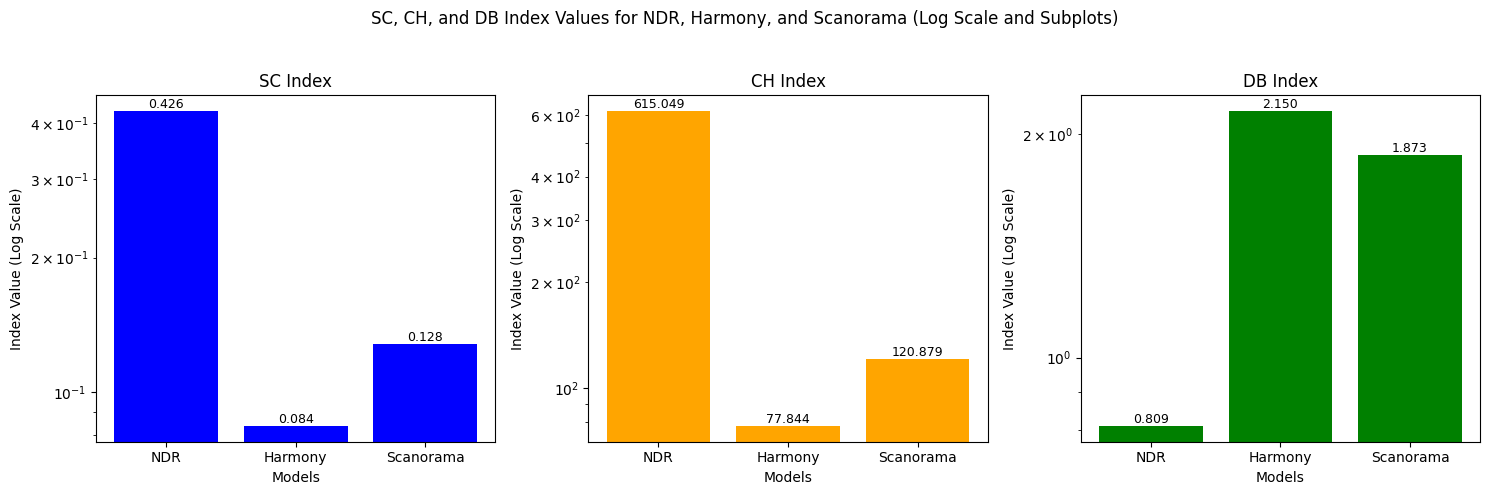

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data values provided
models = ['NDR', 'Harmony', 'Scanorama']
metrics = ['SC', 'CH', 'DB']
values = [
    (0.42644295, 615.0494557494129, 0.8090029498682882),  # NDR
    (0.08384853, 77.84350217489362, 2.1495778372812633),  # Harmony
    (0.12828209, 120.87879981817562, 1.8728363433310133)  # Scanorama
]

# Replotting with logarithmic scale on Y-axis and individual subplots for each metric
values_transposed = list(zip(*values))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors = ['blue', 'orange', 'green']

# Looping over each metric and its values to plot them separately with a log scale
for i, (metric_values, metric) in enumerate(zip(values_transposed, metrics)):
    axes[i].bar(models, metric_values, color=colors[i])
    axes[i].set_title(f"{metric} Index")
    axes[i].set_yscale("log")  # Applying log scale
    axes[i].set_xlabel("Models")
    axes[i].set_ylabel("Index Value (Log Scale)")

    # Displaying values on top of each bar with three decimal precision
    for j, val in enumerate(metric_values):
        axes[i].text(j, val, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle("SC, CH, and DB Index Values for NDR, Harmony, and Scanorama (Log Scale and Subplots)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
